In [1]:
# Импорт необходимых библиотек
import time
import numpy as np
from gym_art.quadrotor_multi.quad_experience_replay import ExperienceReplayWrapper
from gym_art.quadrotor_multi.quadrotor_multi import QuadrotorEnvMulti


In [2]:
# Функция создания среды
def create_env(num_agents, 
               use_numba=False, 
               use_replay_buffer=False, 
               episode_duration=15, 
               quads_render=False
               ):
    quad = 'Crazyflie'
    dyn_randomize_every = dyn_randomization_ratio = None

    episode_duration = episode_duration  # seconds

    raw_control = True
    raw_control_zero_middle = False

    sampler_1 = None
    if dyn_randomization_ratio is not None:
        sampler_1 = dict(type="RelativeSampler", noise_ratio=dyn_randomization_ratio, sampler="normal")

    sense_noise = 'default'

    dynamics_change = dict(noise=dict(thrust_noise_ratio=0.05), damp=dict(vel=0, omega_quadratic=0))
   
    # Используем коэффициенты наград по умолчанию
    rew_coeff = dict(
        pos=1.,                     # награда за точность позиционирования
        effort=0.05,                # штраф за использование энергии
        action_change=0., # штраф за резкие изменения управления
        crash=1.,         # штраф за столкновения
        orient=1.,        # награда за правильную ориентацию
        yaw=0.,          # награда за контроль рыскания
        rot=0.,          # награда за вращение
        attitude=0.,      # награда за положение
        spin=0.1,        # штраф за вращение вокруг оси
        vel=0.,          # награда за контроль скорости
        quadcol_bin=5.,  # штраф за столкновения между квадрокоптерами
        quadcol_bin_smooth_max=4., # сглаженный штраф за столкновения
        quadcol_bin_obst=5.       # штраф за столкновения с препятствиями
        )
   # Создание среды с полным набором параметров
    env = QuadrotorEnvMulti(
        # Основные параметры
        num_agents=num_agents,
        dynamics_params=quad,
        raw_control=raw_control,
        raw_control_zero_middle=raw_control_zero_middle,
        
        # Параметры динамики и шума
        dynamics_randomize_every=dyn_randomize_every,
        dynamics_change=dynamics_change,
        dyn_sampler_1=sampler_1,
        sense_noise=sense_noise,
        init_random_state=False,
        
        # Временные параметры
        ep_time=episode_duration,
        
        #коэффициенты наград
        rew_coeff=rew_coeff,
        # Параметры вычислений
        use_numba=use_numba,
        use_replay_buffer=use_replay_buffer,
        
        # Параметры наблюдений
        obs_repr='xyz_vxyz_R_omega',  # Формат наблюдений: позиция, скорость, ориентация, угл.скорость
                
        # Параметры взаимодействия агентов
        neighbor_visible_num=0,  # Количество видимых соседей
        neighbor_obs_type='none',  # Тип наблюдений за соседями
        
        # Параметры столкновений
        collision_hitbox_radius=0.5,  # Радиус столкновений
        collision_falloff_radius=1.0,  # Радиус затухания столкновений
        
        # Параметры препятствий
        use_obstacles=False,  # Использование препятствий
        obst_density=0.0,    # Плотность препятствий
        obst_size=0.5,       # Размер препятствий
        obst_spawn_area=[8.0, 8.0],  # Область появления препятствий
        
        # Дополнительные физические эффекты
        use_downwash=False,  # Эффект воздушного потока
        
        # Параметры среды
        quads_mode='static_same_goal',  # Режим работы квадрокоптеров
        room_dims=[8.0, 8.0, 5.0],      # Размеры комнаты [x, y, z]
        
        # Параметры визуализации
        quads_view_mode=['topdown','side'],  # Режим отображения
        # [topdown, global, chase, side, corner0, corner1, corner2, corner3, topdownfollow]
        quads_render=quads_render            # Включение рендеринга
    )
    return env

In [3]:
# Тест 1: Базовая функциональность
def test_basic_functionality():
    num_agents = 2
    env = create_env(num_agents)
    
    # Проверка инициализации
    print(f"Количество агентов: {env.num_agents}")
    
    # Получение начального наблюдения
    obs = env.reset()
    print(f"Форма наблюдения: {np.array(obs).shape}")
    
    # Тест одного шага
    actions = [env.action_space.sample() for _ in range(num_agents)]
    obs, rewards, dones, infos = env.step(actions)
    
    print(f"Награды: {rewards}")
    print(f"Завершения: {dones}")
    
    env.close()


In [4]:
print("=== Тест базовой функциональности ===")
test_basic_functionality()

=== Тест базовой функциональности ===
Observation components: ['xyz', 'vxyz', 'R', 'omega']
Observation components: ['xyz', 'vxyz', 'R', 'omega']
Количество агентов: 2
Форма наблюдения: (2, 18)


/home/fire_tech/miniconda3/envs/swarm-rlc/lib/python3.11/site-packages/gymnasium/spaces/box.py:130: UserWarning: WARN: Box bound precision lowered by casting to float32
  gym.logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Награды: [-0.022881175015097736, -0.021283497161014898]
Завершения: [False, False]


----------------------------------------------------------------------------

In [1]:
import numpy as np
from gym_art.quadrotor_multi.quadrotor_single import QuadrotorSingle
from gym_art.quadrotor_multi.scenarios.static_same_goal import Scenario_static_same_goal


In [2]:
# Смотрим аргументы конструктора
import inspect
print(inspect.signature(QuadrotorSingle.__init__))
print("\nПараметры конструктора:")
for param in inspect.signature(QuadrotorSingle.__init__).parameters.values():
    print(f"{param.name}: {param.default}")


(self, dynamics_params='DefaultQuad', dynamics_change=None, dynamics_randomize_every=None, dyn_sampler_1=None, dyn_sampler_2=None, raw_control=True, raw_control_zero_middle=True, dim_mode='3D', tf_control=False, sim_freq=200.0, sim_steps=2, obs_repr='xyz_vxyz_R_omega', ep_time=7, room_dims=(10.0, 10.0, 10.0), init_random_state=False, sense_noise=None, verbose=False, gravity=9.81, t2w_std=0.005, t2t_std=0.0005, excite=False, dynamics_simplification=False, use_numba=False, neighbor_obs_type='none', num_agents=1, num_use_neighbor_obs=0, use_obstacles=False)

Параметры конструктора:
self: <class 'inspect._empty'>
dynamics_params: DefaultQuad
dynamics_change: None
dynamics_randomize_every: None
dyn_sampler_1: None
dyn_sampler_2: None
raw_control: True
raw_control_zero_middle: True
dim_mode: 3D
tf_control: False
sim_freq: 200.0
sim_steps: 2
obs_repr: xyz_vxyz_R_omega
ep_time: 7
room_dims: (10.0, 10.0, 10.0)
init_random_state: False
sense_noise: None
verbose: False
gravity: 9.81
t2w_std: 0.00

In [3]:

# 1. Создаем базовую конфигурацию
config = {
    'num_agents': 1,
    'room_dims': [3., 3., 3.],
    'quads_mode': 'static_same_goal',
    'obs_repr': 'xyz_vxyz_R_omega',
    'ep_time': 15.0
}

# 2. Инициализируем среду
env = QuadrotorSingle(
    dynamics_params="DefaultQuad",
    raw_control=True,
    dim_mode='3D',
    sim_freq=200.,
    room_dims=config['room_dims'],
    sense_noise=None,  # Явно отключаем шум
    init_random_state=False,  # Отключаем случайную инициализацию
    raw_control_zero_middle = False
)

env.raw_control_zero_middl=False
# Устанавливаем начальную точку спавна и цель
env.spawn_point = np.array([0.0, 0.0, 0.0])
env.goal = np.array([0.0, 0.0, 2.0])  # Устанавливаем цель до reset()
 # Устанавливаем нулевой размер области инициализации
env.box = 0.01

# Добавляем коэффициенты вознаграждения
env.rew_coeff = {
    "pos": 1.0,
    "effort": 0.05,
    "crash": 1.0,
    "orient": 0.1,
    "spin": 0.1
}

# 3. Создаем сценарий
scenario = Scenario_static_same_goal(
    quads_mode=config['quads_mode'],
    envs=[env],
    num_agents=config['num_agents'],
    room_dims=config['room_dims']
)


Observation components: ['xyz', 'vxyz', 'R', 'omega']


/home/fire_tech/miniconda3/envs/swarm-rlc/lib/python3.11/site-packages/gymnasium/spaces/box.py:130: UserWarning: WARN: Box bound precision lowered by casting to float32
  gym.logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


In [4]:
# Смотрим аргументы конструктора среды
import inspect
print(inspect.signature(env.__init__))
print("\nПараметры конструктора:")
for param in inspect.signature(env.__init__).parameters.values():
    print(f"{param.name}: {param.default}")


(dynamics_params='DefaultQuad', dynamics_change=None, dynamics_randomize_every=None, dyn_sampler_1=None, dyn_sampler_2=None, raw_control=True, raw_control_zero_middle=True, dim_mode='3D', tf_control=False, sim_freq=200.0, sim_steps=2, obs_repr='xyz_vxyz_R_omega', ep_time=7, room_dims=(10.0, 10.0, 10.0), init_random_state=False, sense_noise=None, verbose=False, gravity=9.81, t2w_std=0.005, t2t_std=0.0005, excite=False, dynamics_simplification=False, use_numba=False, neighbor_obs_type='none', num_agents=1, num_use_neighbor_obs=0, use_obstacles=False)

Параметры конструктора:
dynamics_params: DefaultQuad
dynamics_change: None
dynamics_randomize_every: None
dyn_sampler_1: None
dyn_sampler_2: None
raw_control: True
raw_control_zero_middle: True
dim_mode: 3D
tf_control: False
sim_freq: 200.0
sim_steps: 2
obs_repr: xyz_vxyz_R_omega
ep_time: 7
room_dims: (10.0, 10.0, 10.0)
init_random_state: False
sense_noise: None
verbose: False
gravity: 9.81
t2w_std: 0.005
t2t_std: 0.0005
excite: False
dynam

In [5]:
# Проверим какие атрибуты есть у объекта sense_noise
print("Доступные атрибуты sense_noise:")
for attr in dir(env.sense_noise):
    if not attr.startswith('__'):
        print(attr)


Доступные атрибуты sense_noise:
acc_dynamic_noise_ratio
acc_static_noise_std
add_noise
add_noise_numba
add_noise_to_omega
bypass
gyro_bias
gyro_bias_correlation_time
gyro_noise_density
gyro_norm_std
gyro_random_walk
pos_norm_std
pos_unif_range
quat_norm_std
quat_unif_range
vel_norm_std
vel_unif_range


In [6]:
# Проверяем параметры шума
print("Параметры шума позиции:")
print("pos_norm_std:", env.sense_noise.pos_norm_std)
print("pos_unif_range:", env.sense_noise.pos_unif_range)

print("\nПараметры шума скорости:")
print("vel_norm_std:", env.sense_noise.vel_norm_std)
print("vel_unif_range:", env.sense_noise.vel_unif_range)

print("\nПараметры шума кватерниона:")
print("quat_norm_std:", env.sense_noise.quat_norm_std)
print("quat_unif_range:", env.sense_noise.quat_unif_range)

print("\nПараметры шума гироскопа:")
print("gyro_noise_density:", env.sense_noise.gyro_noise_density)
print("gyro_random_walk:", env.sense_noise.gyro_random_walk)
print("gyro_bias:", env.sense_noise.gyro_bias)
print("gyro_bias_correlation_time:", env.sense_noise.gyro_bias_correlation_time)



Параметры шума позиции:
pos_norm_std: 0.005
pos_unif_range: 0.0

Параметры шума скорости:
vel_norm_std: 0.01
vel_unif_range: 0.0

Параметры шума кватерниона:
quat_norm_std: 0.0
quat_unif_range: 0.0

Параметры шума гироскопа:
gyro_noise_density: 0.000175
gyro_random_walk: 0.0105
gyro_bias: [0. 0. 0.]
gyro_bias_correlation_time: 1000.0


In [7]:
obs = env.reset()

print("Полный анализ состояния после сброса:")
print("1. Относительная позиция (xyz):", np.round(obs[:3], 4))
print("2. Скорость (vxyz):", np.round(obs[3:6], 4))
print("3. Матрица поворота (R):", np.round(obs[6:15], 4))
print("4. Угловая скорость (omega):", np.round(obs[15:18], 4))

# Дополнительная информация
print("\nДополнительно:")
print("Абсолютная позиция:", np.round(obs[:3] + env.goal, 4))
print("Цель:", np.round(env.goal, 4))
print("Размерность вектора состояния:", obs.shape)


Полный анализ состояния после сброса:
1. Относительная позиция (xyz): [-0.0061 -0.0041 -1.    ]
2. Скорость (vxyz): [0. 0. 0.]
3. Матрица поворота (R): [ 0.6004 -0.7997  0.      0.7997  0.6004  0.      0.      0.      1.    ]
4. Угловая скорость (omega): [0. 0. 0.]

Дополнительно:
Абсолютная позиция: [-0.0061 -0.0041  1.    ]
Цель: [0. 0. 2.]
Размерность вектора состояния: (18,)


In [8]:
#Параметры  управления агентом
print(f"Raw control mode: {env.raw_control}")
print(f"Action space: {env.action_space}")
print(f"Controller type: {type(env.controller)}")

Raw control mode: True
Action space: Box(0.0, 1.0, (4,), float32)
Controller type: <class 'gym_art.quadrotor_multi.quadrotor_control.RawControl'>


In [27]:
#Сброс среды и выполнение одного шага с постоянной тягой 

# Сброс среды и получение начального состояния
obs_initial = env.reset()
abs_pos_initial = obs_initial[:3] + env.goal

print("НАЧАЛЬНОЕ ПОЛОЖЕНИЕ:")
print("Абсолютные координаты (xyz):", np.round(abs_pos_initial, 4))
print("Скорость (vxyz):", np.round(obs_initial[3:6], 4))
print("-" * 50)

# Делаем шаг с одинаковой тягой всех двигателей
action = np.array([1.0, 1.0, 1.0, 1.0]) *0.9 # 50% тяги на всех двигателях
obs_step, reward, done, info = env.step(action)
abs_pos_step = obs_step[:3] + env.goal

print("ПОЛОЖЕНИЕ ПОСЛЕ ШАГА:")
print("Абсолютные координаты (xyz):", np.round(abs_pos_step, 4))
print("Скорость (vxyz):", np.round(obs_step[3:6], 4))

print("\nИЗМЕНЕНИЕ ПОЛОЖЕНИЯ:")
print("Δ координаты:", np.round(abs_pos_step - abs_pos_initial, 4))


НАЧАЛЬНОЕ ПОЛОЖЕНИЕ:
Абсолютные координаты (xyz): [-0.0086 -0.002   1.    ]
Скорость (vxyz): [0. 0. 0.]
--------------------------------------------------
ПОЛОЖЕНИЕ ПОСЛЕ ШАГА:
Абсолютные координаты (xyz): [-0.0086 -0.002   1.0004]
Скорость (vxyz): [-0.      0.      0.1491]

ИЗМЕНЕНИЕ ПОЛОЖЕНИЯ:
Δ координаты: [0.     0.     0.0004]


In [28]:
#Сброс среды и выполнение 5 шага с постоянной тягой 

# Сброс среды
obs = env.reset()
abs_pos = obs[:3] + env.goal

print("НАЧАЛЬНОЕ ПОЛОЖЕНИЕ:")
print("Абсолютные координаты (xyz):", np.round(abs_pos, 4))
print("Скорость (vxyz):", np.round(obs[3:6], 4))
print("-" * 50)

# Делаем 5 шагов с одинаковой тягой
action = np.array([0.5, 0.5, 0.5, 0.5])
for i in range(5):
    obs, reward, done, info = env.step(action)
    abs_pos = obs[:3] + env.goal
    
    print(f"ШАГ {i+1}:")
    print("Абсолютные координаты (xyz):", np.round(abs_pos, 4))
    print("Скорость (vxyz):", np.round(obs[3:6], 4))
    print("-" * 30)


НАЧАЛЬНОЕ ПОЛОЖЕНИЕ:
Абсолютные координаты (xyz): [-0.0089  0.007   1.    ]
Скорость (vxyz): [0. 0. 0.]
--------------------------------------------------
ШАГ 1:
Абсолютные координаты (xyz): [-0.0089  0.007   1.0001]
Скорость (vxyz): [-0.     -0.      0.0384]
------------------------------
ШАГ 2:
Абсолютные координаты (xyz): [-0.0089  0.007   1.0006]
Скорость (vxyz): [-0.     -0.      0.0763]
------------------------------
ШАГ 3:
Абсолютные координаты (xyz): [-0.0089  0.007   1.0014]
Скорость (vxyz): [-1.00e-04 -0.00e+00  1.15e-01]
------------------------------
ШАГ 4:
Абсолютные координаты (xyz): [-0.0089  0.007   1.0027]
Скорость (vxyz): [-0.0004 -0.      0.1537]
------------------------------
ШАГ 5:
Абсолютные координаты (xyz): [-0.0089  0.007   1.0043]
Скорость (vxyz): [-7.000e-04  1.000e-04  1.929e-01]
------------------------------


In [29]:
# Сброс среды
obs = env.reset()
abs_pos = obs[:3] + env.goal

print("НАЧАЛЬНОЕ ПОЛОЖЕНИЕ:")
print("Абсолютные координаты (xyz):", np.round(abs_pos, 4))
print("Скорость (vxyz):", np.round(obs[3:6], 4))
print("Матрица поворота:", np.round(obs[6:15], 4))
print("Угловые скорости:", np.round(obs[15:18], 4))
print("-" * 50)

# Делаем 5 шагов с одинаковой тягой
action = np.array([0.5, 0.5, 0.5, 0.5])
for i in range(5):
    obs, reward, done, info = env.step(action)
    abs_pos = obs[:3] + env.goal
    
    print(f"ШАГ {i+1}:")
    print("Абсолютные координаты (xyz):", np.round(abs_pos, 4))
    print("Скорость (vxyz):", np.round(obs[3:6], 4))
    print("Матрица поворота:", np.round(obs[6:15], 4))
    print("Угловые скорости:", np.round(obs[15:18], 4))
    print("-" * 30)


НАЧАЛЬНОЕ ПОЛОЖЕНИЕ:
Абсолютные координаты (xyz): [-9.4e-03 -3.0e-04  1.0e+00]
Скорость (vxyz): [0. 0. 0.]
Матрица поворота: [ 0.9887  0.1502  0.     -0.1502  0.9887  0.      0.      0.      1.    ]
Угловые скорости: [0. 0. 0.]
--------------------------------------------------
ШАГ 1:
Абсолютные координаты (xyz): [-9.4000e-03 -3.0000e-04  1.0001e+00]
Скорость (vxyz): [-0.     -0.      0.0394]
Матрица поворота: [ 9.887e-01  1.502e-01 -0.000e+00 -1.502e-01  9.887e-01 -1.000e-04
  0.000e+00  1.000e-04  1.000e+00]
Угловые скорости: [ 0.0432 -0.0107  0.0008]
------------------------------
ШАГ 2:
Абсолютные координаты (xyz): [-9.4000e-03 -3.0000e-04  1.0006e+00]
Скорость (vxyz): [-0.     -0.0001  0.0786]
Матрица поворота: [ 9.887e-01  1.502e-01 -2.000e-04 -1.502e-01  9.887e-01 -6.000e-04
  1.000e-04  6.000e-04  1.000e+00]
Угловые скорости: [ 0.0727  0.0075 -0.0011]
------------------------------
ШАГ 3:
Абсолютные координаты (xyz): [-9.4000e-03 -3.0000e-04  1.0015e+00]
Скорость (vxyz): [-0.  

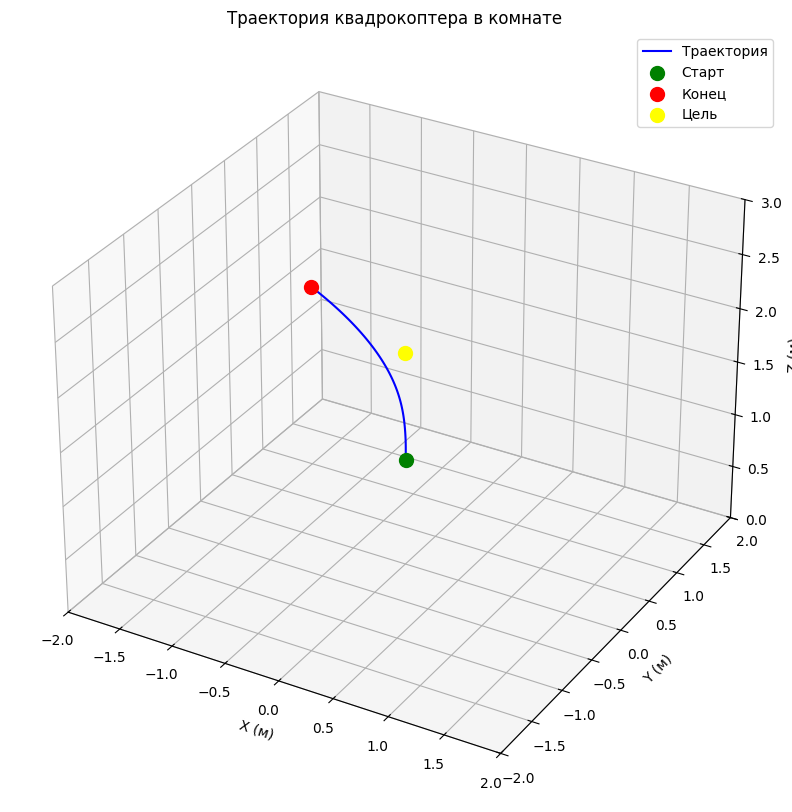

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

f1=f2=f3=f4 = 0.5

# Параметры симуляции
n_steps = 100
thrust = np.array([f1,f2,f3,f4])

# Массивы для хранения траектории
positions = []

# Сброс среды и симуляция
obs = env.reset()
goal = env.goal
abs_pos = obs[:3] + goal
positions.append(abs_pos)

for _ in range(n_steps):
    obs, _, _, _ = env.step(thrust)
    abs_pos = obs[:3] + goal
    positions.append(abs_pos)

positions = np.array(positions)

# Создаем 3D график
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Рисуем траекторию и точки
ax.plot(positions[:, 0], positions[:, 1], positions[:, 2], 'b-', label='Траектория')
ax.scatter(positions[0, 0], positions[0, 1], positions[0, 2], color='g', s=100, label='Старт')
ax.scatter(positions[-1, 0], positions[-1, 1], positions[-1, 2], color='r', s=100, label='Конец')
ax.scatter(goal[0], goal[1], goal[2], color='yellow', s=100, label='Цель')

# Настройка масштабов комнаты
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
ax.set_zlim([0, 3])

# Настройка графика
ax.set_xlabel('X (м)')
ax.set_ylabel('Y (м)')
ax.set_zlabel('Z (м)')
ax.set_title('Траектория квадрокоптера в комнате')
ax.legend()

# Добавляем сетку
ax.grid(True)

plt.show()


Сделаем более детальный анализ:
Возможные причины отклонения:
Накопление численных ошибок в симуляции
Неточности в физической модели
Возможные проблемы с начальной ориентацией

In [45]:
n_steps = 100
thrust = np.array([0.5, 0.5, 0.5, 0.5])
positions = []
rotations = []
angular_velocities = []

# Сброс и симуляция
obs = env.reset()
goal = env.goal
abs_pos = obs[:3] + goal
positions.append(abs_pos)
rotations.append(obs[6:15])
angular_velocities.append(obs[15:18])

for i in range(n_steps):
    obs, _, _, _ = env.step(thrust)
    abs_pos = obs[:3] + goal
    positions.append(abs_pos)
    rotations.append(obs[6:15])
    angular_velocities.append(obs[15:18])

positions = np.array(positions)
rotations = np.array(rotations)
angular_velocities = np.array(angular_velocities)

# Анализ отклонения от вертикали
horizontal_drift = np.sqrt((positions[-1,0] - positions[0,0])**2 + 
                          (positions[-1,1] - positions[0,1])**2)
vertical_rise = positions[-1,2] - positions[0,2]

print(f"Горизонтальный дрейф: {horizontal_drift:.4f} м")
print(f"Вертикальный подъём: {vertical_rise:.4f} м")
print(f"Отношение дрейф/подъём: {(horizontal_drift/vertical_rise):.4f}")


Горизонтальный дрейф: 2.1247 м
Вертикальный подъём: 3.0000 м
Отношение дрейф/подъём: 0.7082


Этот код проверит:

Начальные координаты
Корректность матрицы поворота
Ортогональность матрицы (важное свойство)
Начальные угловые скорости
Это поможет выявить возможные проблемы в начальных условиях.

In [40]:
# Сделаем несколько сбросов среды для анализа начальных условий
n_resets = 5

for i in range(n_resets):
    obs = env.reset()
    abs_pos = obs[:3] + env.goal
    
    print(f"\nСброС {i+1}:")
    print("1. Абсолютные координаты (xyz):", np.round(abs_pos, 4))
    print("2. Матрица поворота:")
    R = obs[6:15].reshape(3,3)
    print(np.round(R, 4))
    print("3. Проверка ортогональности матрицы:")
    print(np.round(np.dot(R.T, R), 4))  # Должна быть единичной
    print("4. Угловые скорости:", np.round(obs[15:18], 4))
    print("-" * 50)



СброС 1:
1. Абсолютные координаты (xyz): [ 0.0022 -0.0038  0.    ]
2. Матрица поворота:
[[-0.9922 -0.1244  0.    ]
 [ 0.1244 -0.9922  0.    ]
 [ 0.      0.      1.    ]]
3. Проверка ортогональности матрицы:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
4. Угловые скорости: [0. 0. 0.]
--------------------------------------------------

СброС 2:
1. Абсолютные координаты (xyz): [ 0.0073 -0.      0.    ]
2. Матрица поворота:
[[-0.9958 -0.0913  0.    ]
 [ 0.0913 -0.9958  0.    ]
 [ 0.      0.      1.    ]]
3. Проверка ортогональности матрицы:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
4. Угловые скорости: [0. 0. 0.]
--------------------------------------------------

СброС 3:
1. Абсолютные координаты (xyz): [ 0.0078 -0.0067  0.    ]
2. Матрица поворота:
[[-0.7668 -0.6419  0.    ]
 [ 0.6419 -0.7668  0.    ]
 [ 0.      0.      1.    ]]
3. Проверка ортогональности матрицы:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
4. Угловые скорости: [0. 0. 0.]
--------------------------------------------------

СброС 4:
1. Абс

Заключение:

Начальные условия корректны
Дрон всегда начинает полет из горизонтального положения
Проблема дрейфа не связана с начальными условиями

## Проверка динамики 

In [1]:
# Импорты
from gym_art.quadrotor_multi.quadrotor_dynamics import QuadrotorDynamics
from gym_art.quadrotor_multi.quadrotor_randomization import Crazyflie, DefaultQuad, ConstValueSampler, RandomQuad, MediumQuad
import numpy as np
import matplotlib.pyplot as plt

# Константы из проекта
GRAV = 9.81
SIM_FREQ = 200  # Частота симуляции 200 Гц 
DT = 1.0 / SIM_FREQ  # Шаг времени 0.005 секунды


In [129]:

# Получаем параметры модели Crazyflie
#model_params = DefaultQuad().sample() 
model_params = Crazyflie().sample()
#model_params1 = Crazyflie().sample()
#model_params = RandomQuad().sample()
#model_params = MediumQuad().sample()
model_params

{'geom': {'body': {'l': 0.03, 'w': 0.03, 'h': 0.02, 'm': 0.019899999999999998},
  'payload': {'l': 0.035, 'w': 0.045, 'h': 0.015, 'm': 0.00905},
  'arms': {'l': 0.022, 'w': 0.005, 'h': 0.005, 'm': 0.001},
  'motors': {'h': 0.02, 'r': 0.0035, 'm': 0.0036},
  'propellers': {'h': 0.002, 'r': 0.026, 'm': 0.00035},
  'motor_pos': {'xyz': [0.0325, 0.0325, 0.0]},
  'arms_pos': {'angle': 45.0, 'z': 0.0},
  'payload_pos': {'xy': [0.0, 0.0], 'z_sign': -1}},
 'damp': {'vel': 0.0, 'omega_quadratic': 0.0},
 'noise': {'thrust_noise_ratio': 0.05},
 'motor': {'thrust_to_weight': 1.9,
  'assymetry': [1.0, 1.0, 1.0, 1.0],
  'torque_to_thrust': 0.005964552,
  'linearity': 1.0,
  'C_drag': 0.0,
  'C_roll': 0.0,
  'damp_time_up': 0.15,
  'damp_time_down': 0.15}}

In [130]:
# Упрощаем модель:
model_params["noise"]["thrust_noise_ratio"] = 0.0          # убираем шум
model_params["motor"]["damp_time_up"]       = 0.0        # мгновенный разгон мотора
model_params["motor"]["damp_time_down"]     = 0.0         # мгновенная остановка

In [11]:
# Выводим все параметры модели подробно
print("Геометрические параметры:")
print("\nКорпус (body):")
print(f"Длина: {model_params['geom']['body']['l']} м")
print(f"Ширина: {model_params['geom']['body']['w']} м") 
print(f"Высота: {model_params['geom']['body']['h']} м")
print(f"Масса: {model_params['geom']['body']['m']} кг")

print("\nПолезная нагрузка (payload):")
print(f"Длина: {model_params['geom']['payload']['l']} м")
print(f"Ширина: {model_params['geom']['payload']['w']} м")
print(f"Высота: {model_params['geom']['payload']['h']} м") 
print(f"Масса: {model_params['geom']['payload']['m']} кг")

print("\nЛучи (arms):")
print(f"Длина: {model_params['geom']['arms']['l']} м")
print(f"Ширина: {model_params['geom']['arms']['w']} м")
print(f"Высота: {model_params['geom']['arms']['h']} м")
print(f"Масса: {model_params['geom']['arms']['m']} кг")

print("\nМоторы (motors):")
print(f"Высота: {model_params['geom']['motors']['h']} м")
print(f"Радиус: {model_params['geom']['motors']['r']} м")
print(f"Масса: {model_params['geom']['motors']['m']} кг")

print("\nПропеллеры (propellers):")
print(f"Высота: {model_params['geom']['propellers']['h']} м")
print(f"Радиус: {model_params['geom']['propellers']['r']} м")
print(f"Масса: {model_params['geom']['propellers']['m']} кг")

print("\nПозиция моторов:")
print(f"XYZ: {model_params['geom']['motor_pos']['xyz']} м")

print("\nПараметры двигателей:")
print(f"Соотношение тяга/вес: {model_params['motor']['thrust_to_weight']}")
print(f"Крутящий момент к тяге: {model_params['motor']['torque_to_thrust']}")
print(f"Время отклика (разгон): {model_params['motor']['damp_time_up']} с")
print(f"Время отклика (торможение): {model_params['motor']['damp_time_down']} с")
print(f"Линейность: {model_params['motor']['linearity']}")
print(f"Асимметрия: {model_params['motor']['assymetry']}")

print("\nПараметры демпфирования:")
print(f"Скорость: {model_params['damp']['vel']}")
print(f"Квадратичное по угловой скорости: {model_params['damp']['omega_quadratic']}")

print("\nПараметры шума:")
print(f"Шум тяги: {model_params['noise']['thrust_noise_ratio']}")

# Расчет полной массы
total_mass = (model_params['geom']['body']['m'] + 
              model_params['geom']['payload']['m'] + 
              4 * model_params['geom']['motors']['m'] +
              4 * model_params['geom']['propellers']['m'] +
              4 * model_params['geom']['arms']['m'])

print(f"\nПолная масса квадрокоптера: {total_mass:.6f} кг")


Геометрические параметры:

Корпус (body):
Длина: 0.03 м
Ширина: 0.03 м
Высота: 0.02 м
Масса: 0.019899999999999998 кг

Полезная нагрузка (payload):
Длина: 0.035 м
Ширина: 0.045 м
Высота: 0.015 м
Масса: 0.00905 кг

Лучи (arms):
Длина: 0.022 м
Ширина: 0.005 м
Высота: 0.005 м
Масса: 0.001 кг

Моторы (motors):
Высота: 0.02 м
Радиус: 0.0035 м
Масса: 0.0036 кг

Пропеллеры (propellers):
Высота: 0.002 м
Радиус: 0.026 м
Масса: 0.00035 кг

Позиция моторов:
XYZ: [0.0325, 0.0325, 0.0] м

Параметры двигателей:
Соотношение тяга/вес: 1.9
Крутящий момент к тяге: 0.005964552
Время отклика (разгон): 0.0 с
Время отклика (торможение): 0.0 с
Линейность: 1.0
Асимметрия: [1.0, 1.0, 1.0, 1.0]

Параметры демпфирования:
Скорость: 0.0
Квадратичное по угловой скорости: 0.0

Параметры шума:
Шум тяги: 0.0

Полная масса квадрокоптера: 0.048750 кг


In [7]:
# Параметры модели квадрокоптера CrazyFlie Это самописный вариант
model_params = {
    "geom": {
        "arm_length": 0.046,  # Длина луча от центра до мотора в метрах
        "motor_xyz": [[0.046, -0.046, 0],  # Координаты расположения моторов
                     [-0.046, 0.046, 0],   # относительно центра масс
                     [-0.046, -0.046, 0],  # Формат: [x, y, z]
                     [0.046, 0.046, 0]], 
        "m": 0.027,  # Масса дрона в кг
        "I_com": [[1.4e-5, 0, 0],    # Тензор инерции
                  [0, 1.4e-5, 0],     # Момент инерции вокруг осей
                  [0, 0, 2.17e-5]]    # x, y, z соответственно
    },
    "motor": {
        "thrust_to_weight": 2.0,        # Соотношение тяги к весу
        "torque_to_thrust": 0.006,      # Коэффициент момента к тяге
        "linearity": 1.0,               # Линейность характеристики мотора
        "C_drag": 0.0,                  # Коэффициент сопротивления воздуха
        "C_roll": 0.0,                  # Коэффициент крена
        "damp_time_up": 0.15,           # Время отклика мотора при ускорении
        "damp_time_down": 0.15          # Время отклика мотора при торможении
    },
    "noise": {"thrust_noise_ratio": 0.0},  # Уровень шума тяги (0 = без шума)
    "damp": {
        "vel": 0.0,                     # Демпфирование линейной скорости
        "omega_quadratic": 0.0          # Квадратичное демпфирование угловой скорости
    }
}



In [121]:
# Создаем экземпляр динамики квадрокоптера
quad = QuadrotorDynamics(model_params)
quad.dynamics_simplification  = True
# Задаем начальное состояние дрона
initial_pos = np.array([0., 0., 1.])    # Позиция в пространстве [x, y, z]
initial_vel = np.zeros(3)               # Начальная скорость = 0 по всем осям
initial_rot = np.eye(3)                 # Матрица поворота (без начального поворота)
initial_omega = np.zeros(3)             # Угловая скорость = 0 по всем осям

quad.room_box = [[-2.5, -2.5, 0], [2.5, 2.5, 5]]

print("Room box boundaries:", quad.room_box)

# Устанавливаем начальное состояние в симуляторе
quad.set_state(initial_pos, initial_vel, initial_rot, initial_omega)
quad.reset()
quad.thrust_max

Room box boundaries: [[-2.5, -2.5, 0], [2.5, 2.5, 5]]


array([0.22716281, 0.22716281, 0.22716281, 0.22716281])

thrust_max представляет максимальную тягу каждого мотора в Ньютонах (N).

- Значение 0.13734 N для каждого мотора рассчитывается на основе параметров дрона:

- Масса дрона: 0.027 кг
- Соотношение тяги к весу (thrust_to_weight): 2.0
- Количество моторов: 4

Расчет Для одного мотора:
- thrust_max = (масса * GRAV * thrust_to_weight) / 4
- thrust_max = (0.027 * 9.81 * 2.0) / 4 ≈ 0.13734 N


In [108]:
# Проверяем пространство действий
print(f"Action space: {quad.action_space()}")


# Расчет тяги для зависания
hover_thrust = quad.mass * GRAV  # Общая требуемая тяга
thrust_per_motor = hover_thrust / 4.0  # Тяга на каждый мотор
normalized_thrust = thrust_per_motor / quad.thrust_max[0]  # Нормализация до [0, 1]
thrust_cmds = np.ones(4) * normalized_thrust
thrust_cmds

Action space: Box(0.0, 1.0, (4,), float32)


/home/fire_tech/miniconda3/envs/swarm-rlc/lib/python3.11/site-packages/gymnasium/spaces/box.py:130: UserWarning: WARN: Box bound precision lowered by casting to float32
  gym.logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


array([0.52631579, 0.52631579, 0.52631579, 0.52631579])

### Зависание - Взлет

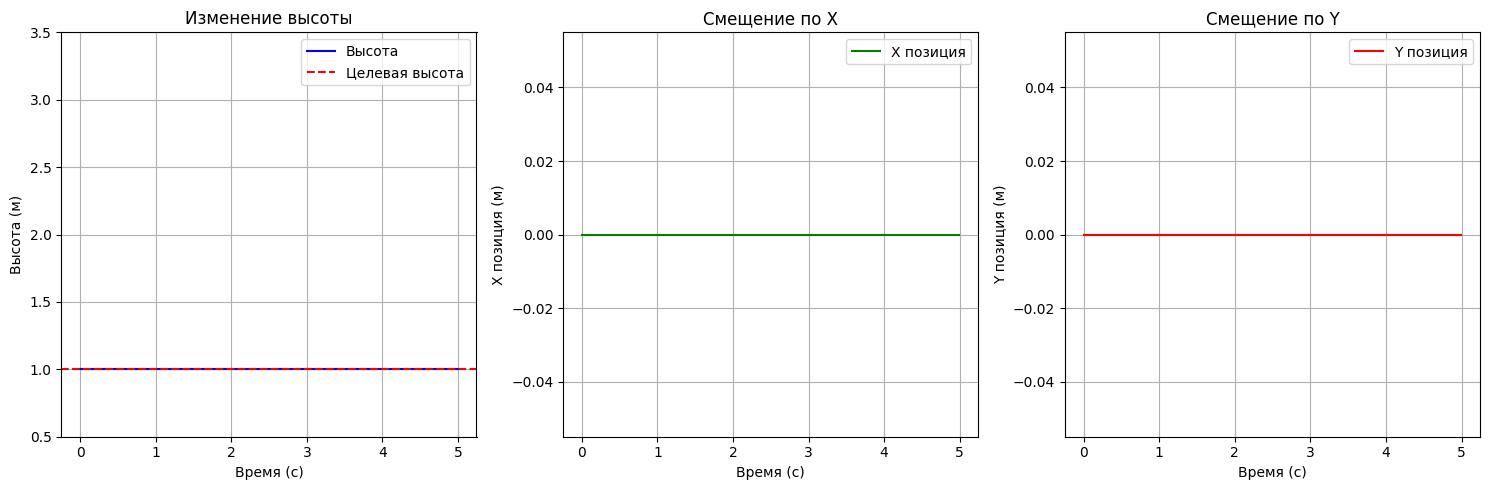


Статистика полета:
Тяга: [0.52631579 0.52631579 0.52631579 0.52631579]
Начальная высота: 1.000 м
Конечная высота: 1.000 м
Максимальное отклонение по X: 0.000 м
Максимальное отклонение по Y: 0.000 м


In [14]:

# Устанавливаем начальное положение квадрокоптера
initial_pos = np.array([0., 0., 1.])  # x=0, y=0, z=1 метр
initial_vel = np.zeros(3)             # начальная скорость по всем осям = 0
initial_rot = np.eye(3)               # начальная матрица поворота (без вращения)
initial_omega = np.zeros(3)           # начальная угловая скорость = 0

# Устанавливаем состояние квадрокоптера
quad.set_state(initial_pos, initial_vel, initial_rot, initial_omega)
quad.reset



# Массивы для сбора данных во время симуляции
time_points = []    # временные точки
heights = []        # высота
x_positions = []    # положение по X
y_positions = []    # положение по Y
velocities = []     # вертикальная скорость

# Симуляция 5 секунд с шагом 5 мс
for t in range(1000):
    # Выполняем шаг симуляции
    quad.step(thrust_cmds, 0.005)
    
    # Сохраняем данные
    time_points.append(t * 0.005)
    heights.append(quad.pos[2])
    x_positions.append(quad.pos[0])
    y_positions.append(quad.pos[1])
    velocities.append(quad.vel[2])
    
    # Выводим состояние каждые 100 шагов
   # if t % 100 == 0:
    #    print(f"\nШаг {t}:")
    #    print(f"Высота: {quad.pos[2]:.3f}")
    #    print(f"Вертикальная скорость: {quad.vel[2]:.3f}")

# Визуализация результатов
plt.figure(figsize=(15, 5))

# График высоты
plt.subplot(131)
plt.plot(time_points, heights, 'b-', label='Высота')
plt.axhline(y=1.0, color='r', linestyle='--', label='Целевая высота')
plt.xlabel('Время (с)')
plt.ylabel('Высота (м)')
plt.title('Изменение высоты')
plt.grid(True)
plt.legend()
plt.ylim(0.5, 3.5)

# График положения по X
plt.subplot(132)
plt.plot(time_points, x_positions, 'g-', label='X позиция')
plt.xlabel('Время (с)')
plt.ylabel('X позиция (м)')
plt.title('Смещение по X')
plt.grid(True)
plt.legend()

# График положения по Y
plt.subplot(133)
plt.plot(time_points, y_positions, 'r-', label='Y позиция')
plt.xlabel('Время (с)')
plt.ylabel('Y позиция (м)')
plt.title('Смещение по Y')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Вывод итоговой статистики
print(f"\nСтатистика полета:")
print(f"Тяга: {thrust_cmds}")
print(f"Начальная высота: {heights[0]:.3f} м")
print(f"Конечная высота: {heights[-1]:.3f} м")
print(f"Максимальное отклонение по X: {max(np.abs(x_positions)):.3f} м")
print(f"Максимальное отклонение по Y: {max(np.abs(y_positions)):.3f} м")


### Проверка динамики

- идеальный квадрокоптер

### проверка динамики вертикального подъёма и снижения.

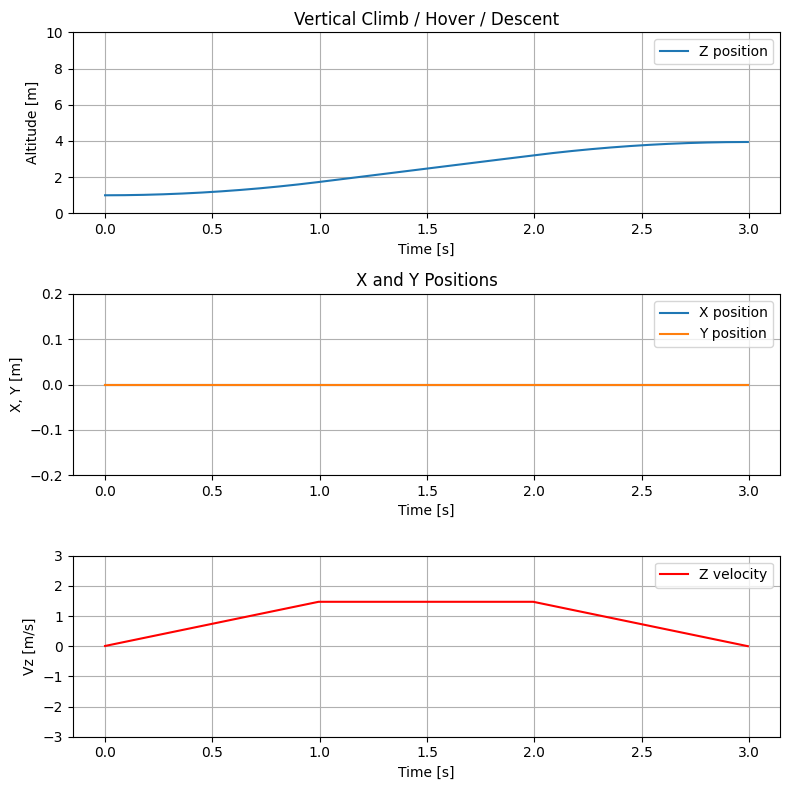

===== Финальное состояние после симуляции =====
pos  = [0.    0.    3.943]
vel  = [ 0.0000000e+00  0.0000000e+00 -6.5399075e-16]
rot = 
{quad_test.rot}
omega= [0. 0. 0.]



In [15]:
# Ниже пример кода, в котором мы не только анализируем движение по оси Z, но и выводим
# координаты x и y после каждого шага симуляции. По умолчанию в данном сценарии x и y 
# не должны меняться (если команда на моторах симметрична и начальные углы равны 0), 
# но мы можем вывести их для наглядности.

def test_vertical_climb_and_descend(steps_ascend=200, steps_hover=200, steps_descend=200):
    """
    Функция для демонстрации вертикального подъёма и спуска.
    steps_ascend  - количество шагов, в течение которых тяга > mg/4 (подъём).
    steps_hover   - количество шагов, в течение которых тяга ≈ mg/4 (зависание).
    steps_descend - количество шагов, в течение которых тяга < mg/4 (снижение).
    Возвращает логи высоты и скорости по оси Z, а также X и Y координаты, и объект динамики.
    """

    quad = QuadrotorDynamics(
        model_params=model_params,
        room_box=None,
        dynamics_steps_num=1,
        dim_mode="3D",
        gravity=GRAV,
        dynamics_simplification=True,
        use_numba=False,
        dt=1/200
    )
    
    # Инициализируем состояние (дрон в точке [0,0,1])
    quad.set_state(position=np.array([0., 0., 1.0]),
                   velocity=np.zeros(3),
                   rotation=np.eye(3),
                   omega=np.zeros(3))
    quad.reset()

    # Масса и максимальная тяга (на 1 винт)
    mass = quad.mass
    thrust_max_1 = quad.thrust_max[0]

    # Расчёт hover thrust (примерно mg/4) и нормализация
    hover_thrust_per_motor = (mass * GRAV) / 4.0
    hover_cmd = hover_thrust_per_motor / thrust_max_1
    
    # Для подъёма задаём тягу чуть выше hover ~ +15%
    climb_cmd = hover_cmd * 1.15
    
    # Для снижения тягу чуть меньше hover ~ -15%
    descend_cmd = hover_cmd * 0.85

    # Логи
    pos_x_log = []
    pos_y_log = []
    pos_z_log = []
    vel_z_log = []
    
    # Отработка подъёма (несколько шагов с повышенной тягой)
    for _ in range(steps_ascend):
        quad.step(np.ones(4) * climb_cmd, quad.dt)
        pos_x_log.append(quad.pos[0])
        pos_y_log.append(quad.pos[1])
        pos_z_log.append(quad.pos[2])
        vel_z_log.append(quad.vel[2])
    
    # Отработка удержания (несколько шагов с hover тягой)
    for _ in range(steps_hover):
        quad.step(np.ones(4) * hover_cmd, quad.dt)
        pos_x_log.append(quad.pos[0])
        pos_y_log.append(quad.pos[1])
        pos_z_log.append(quad.pos[2])
        vel_z_log.append(quad.vel[2])

    # Отработка снижения (несколько шагов с пониженной тягой)
    for _ in range(steps_descend):
        quad.step(np.ones(4) * descend_cmd, quad.dt)
        pos_x_log.append(quad.pos[0])
        pos_y_log.append(quad.pos[1])
        pos_z_log.append(quad.pos[2])
        vel_z_log.append(quad.vel[2])
        
    return pos_x_log, pos_y_log, pos_z_log, vel_z_log, quad

# Теперь запустим тест:
steps_ascend  = 200  # Подъём (~1 сек, если dt=1/200)
steps_hover   = 200
steps_descend = 200

pos_x_log, pos_y_log, pos_z_log, vel_z_log, quad_test = test_vertical_climb_and_descend(
    steps_ascend=steps_ascend,
    steps_hover=steps_hover,
    steps_descend=steps_descend
)

# Формируем временной массив (общее кол-во шагов = сумма трёх этапов)
steps_total = steps_ascend + steps_hover + steps_descend
time_array = np.arange(steps_total) * (1/200)

# Строим графики
fig, axs = plt.subplots(3, 1, figsize=(8, 8))

# График Z
axs[0].plot(time_array, pos_z_log, label='Z position')
axs[0].set_ylim([0, 10])
axs[0].set_xlabel("Time [s]")
axs[0].set_ylabel("Altitude [m]")
axs[0].set_title("Vertical Climb / Hover / Descent")
axs[0].grid()
axs[0].legend()

# График X и Y
axs[1].plot(time_array, pos_x_log, label='X position')
axs[1].plot(time_array, pos_y_log, label='Y position')
axs[1].set_ylim([-0.2, 0.2])
axs[1].set_xlabel("Time [s]")
axs[1].set_ylabel("X, Y [m]")
axs[1].set_title("X and Y Positions")
axs[1].grid()
axs[1].legend()

# График вертикальной скорости
axs[2].plot(time_array, vel_z_log, label='Z velocity', color='red')
axs[2].set_ylim([-3, 3])
axs[2].set_xlabel("Time [s]")
axs[2].set_ylabel("Vz [m/s]")
axs[2].grid()
axs[2].legend()

plt.tight_layout()
plt.show()

# Выводим финальное состояние
print("===== Финальное состояние после симуляции =====")
print(f"pos  = {quad_test.pos}")
print(f"vel  = {quad_test.vel}")
print("rot = \n{quad_test.rot}")
print(f"omega= {quad_test.omega}\n")

# В упрощённой симметричной ситуации X и Y координаты будут оставаться около нуля,
# если нет никаких возмущений или угловых скоростей. 


### Динамическое изменение высоты


Время: 0.0с
Тяга: 0.526
Высота: 1.000
Скорость: 0.000
Ускорение: 0.000

Время: 1.0с
Тяга: 0.626
Высота: 1.000
Скорость: 0.009
Ускорение: 1.864

Время: 2.0с
Тяга: 0.526
Высота: 1.937
Скорость: 1.864
Ускорение: 0.000

Время: 3.0с
Тяга: 0.526
Высота: 3.801
Скорость: 1.864
Ускорение: 0.000

Время: 4.0с
Тяга: 0.526
Высота: 5.664
Скорость: 1.864
Ускорение: 0.000


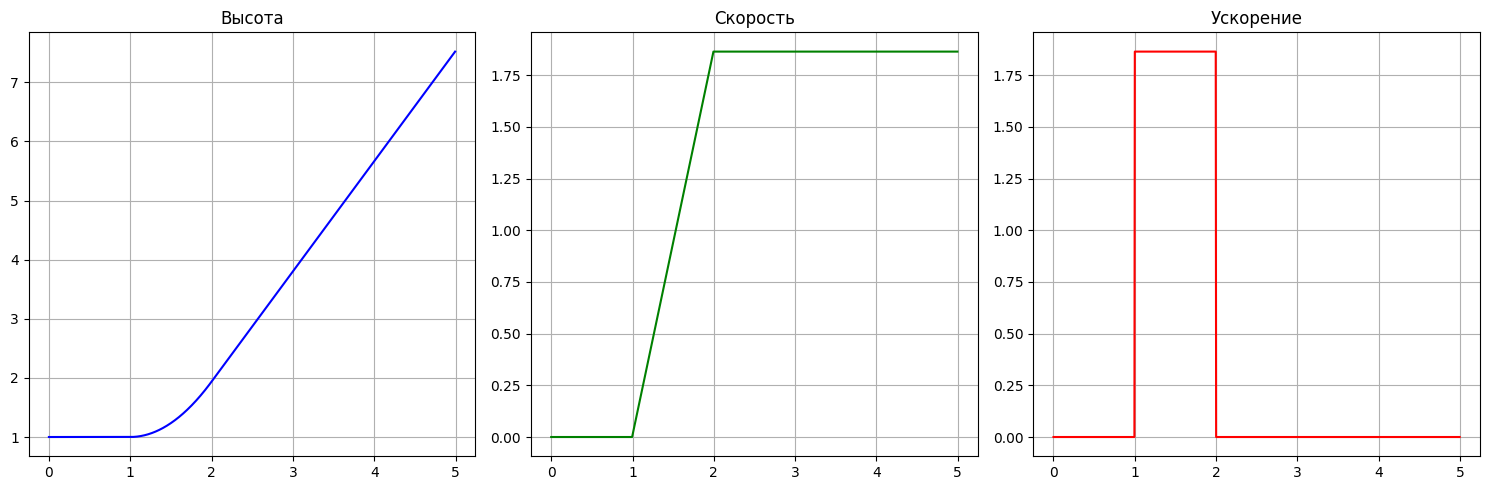

In [16]:
quad = QuadrotorDynamics(
        model_params=model_params,
        room_box=None,
        dynamics_steps_num=1,
        dim_mode="3D",
        gravity=GRAV,
        dynamics_simplification=True,
        use_numba=False,
        dt=1/200
    )
 # Начальные условия
initial_pos = np.array([0., 0., 1.])
initial_vel = np.zeros(3)
initial_rot = np.eye(3)
initial_omega = np.zeros(3)
quad.set_state(initial_pos, initial_vel, initial_rot, initial_omega)
quad.reset()
# Базовая тяга для зависания (компенсация гравитации)
# Масса и максимальная тяга (на 1 винт)
mass = quad.mass
thrust_max_1 = quad.thrust_max[0]

    # Расчёт hover thrust (примерно mg/4) и нормализация
hover_thrust_per_motor = (mass * GRAV) / 4.0
hover_thrust = hover_thrust_per_motor / thrust_max_1
#hover_thrust = 0.5  # 50% тяги для зависания

def get_height_test_thrust(t):
    """
    Более точное управление с учетом гравитации
    """
    if t < 1.0:
        return hover_thrust  # Зависание
    elif t < 2.0:
        return hover_thrust + 0.1  # Подъем
    elif t < 3.0:
        return hover_thrust - 0  # Снижение
    else:
        return hover_thrust  # Возврат к зависанию

# Массивы для данных
time_points = []
heights = []
velocities = []
accelerations = []

# Симуляция
dt = 0.005
steps = int(5.0 / dt)

for t in range(steps):
    current_time = t * dt
    thrust = get_height_test_thrust(current_time)
    thrust_cmds = np.ones(4) * thrust
    
    quad.step(thrust_cmds, quad.dt)
    
    time_points.append(current_time)
    heights.append(quad.pos[2])
    velocities.append(quad.vel[2])
    accelerations.append(quad.acc[2])
    
    if t % 200 == 0:
        print(f"\nВремя: {current_time:.1f}с")
        print(f"Тяга: {thrust:.3f}")
        print(f"Высота: {quad.pos[2]:.3f}")
        print(f"Скорость: {quad.vel[2]:.3f}")
        print(f"Ускорение: {quad.acc[2]:.3f}")

# Визуализация
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.plot(time_points, heights, 'b-')
plt.title('Высота')
plt.grid(True)

plt.subplot(132)
plt.plot(time_points, velocities, 'g-')
plt.title('Скорость')
plt.grid(True)

plt.subplot(133)
plt.plot(time_points, accelerations, 'r-')
plt.title('Ускорение')
plt.grid(True)

plt.tight_layout()
plt.show()


### проверка движения квадрокоптера вперёд, назад, влево, вправо и поворота вокруг оси Z.

In [158]:
def test_forward_motion(steps_forward=1600):
    """
    Функция для демонстрации движения вперед.
    steps_forward - количество шагов движения вперед
    """
    quad = QuadrotorDynamics(
        model_params=model_params,
        room_box=None,
        dynamics_steps_num=1,
        dim_mode="3D",
        gravity=GRAV,
        dynamics_simplification=True,
        use_numba=False,
        dt=1/200
    )

    quad.room_box = [[-2.5, -2.5, 0], [2.5, 2.5, 5]]

    print("Room box boundaries:", quad.room_box)
    # Инициализация начального состояния
    quad.set_state(
        position=np.array([0.0, 0.0, 4.0]),  # Начальная высота 2 метра
        velocity=np.zeros(3),
        rotation=np.eye(3),
        omega=np.zeros(3)
    )
    quad.reset()

    # Расчет команд управления
    mass = quad.mass
    thrust_max_1 = quad.thrust_max[0]
    hover_thrust = (mass * GRAV) / 4.0
    hover_cmd = hover_thrust / thrust_max_1
    print("hover_cmd" , hover_cmd)
    
    # Команды для движения назад
    forward_cmds = np.array([1.001, 1.001, 1.001, 1.001]) * hover_cmd 

    # Команды для движения вперед 
    #forward_cmds = np.array([1.000, 1.0001, 1.0001, 1.000]) * hover_cmd 

       # Команды для движения влево 
    #forward_cmds = np.array([1.0001, 1.0001, 1.000, 1.000]) * hover_cmd 

       # Команды для движения вправо 
    #forward_cmds = np.array([1.000, 1.000, 1.0001, 1.0001]) * hover_cmd 

         # Команды для движения враoщение 
    #forward_cmds = np.array([1.000, 1.0001, 1.000, 1.0001]) * hover_cmd 
    
    print("forward_cmds" , forward_cmds)
    # Логи для записи траектории и углов
    pos_log = []
    angles_log = []  # [roll, pitch, yaw]
    
    # Движение вперед
    for _ in range(steps_forward):
        quad.step(forward_cmds, quad.dt)
        pos_log.append(quad.pos.copy())
        
        # Извлечение углов из матрицы поворота
        roll = np.arctan2(quad.rot[2,1], quad.rot[2,2])
        pitch = np.arctan2(-quad.rot[2,0], np.sqrt(quad.rot[2,1]**2 + quad.rot[2,2]**2))
        yaw = np.arctan2(quad.rot[1,0], quad.rot[0,0])
        angles_log.append([roll, pitch, yaw])

    return np.array(pos_log), np.array(angles_log), quad


In [153]:
# Упрощаем модель:
model_params["noise"]["thrust_noise_ratio"] = 0.0          # убираем шум 0.005
model_params["motor"]["damp_time_up"]       = 0.05        # 0.15 мгновенный разгон мотора
model_params["motor"]["damp_time_down"]     = 0.05         # 0.15 мгновенная остановка

Room box boundaries: [[-2.5, -2.5, 0], [2.5, 2.5, 5]]
hover_cmd 0.5263157894736843
forward_cmds [0.52684211 0.52684211 0.52684211 0.52684211]


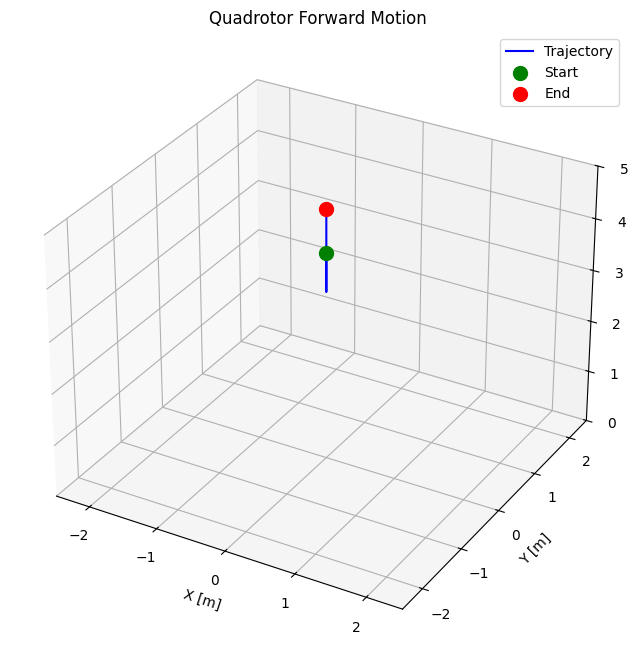

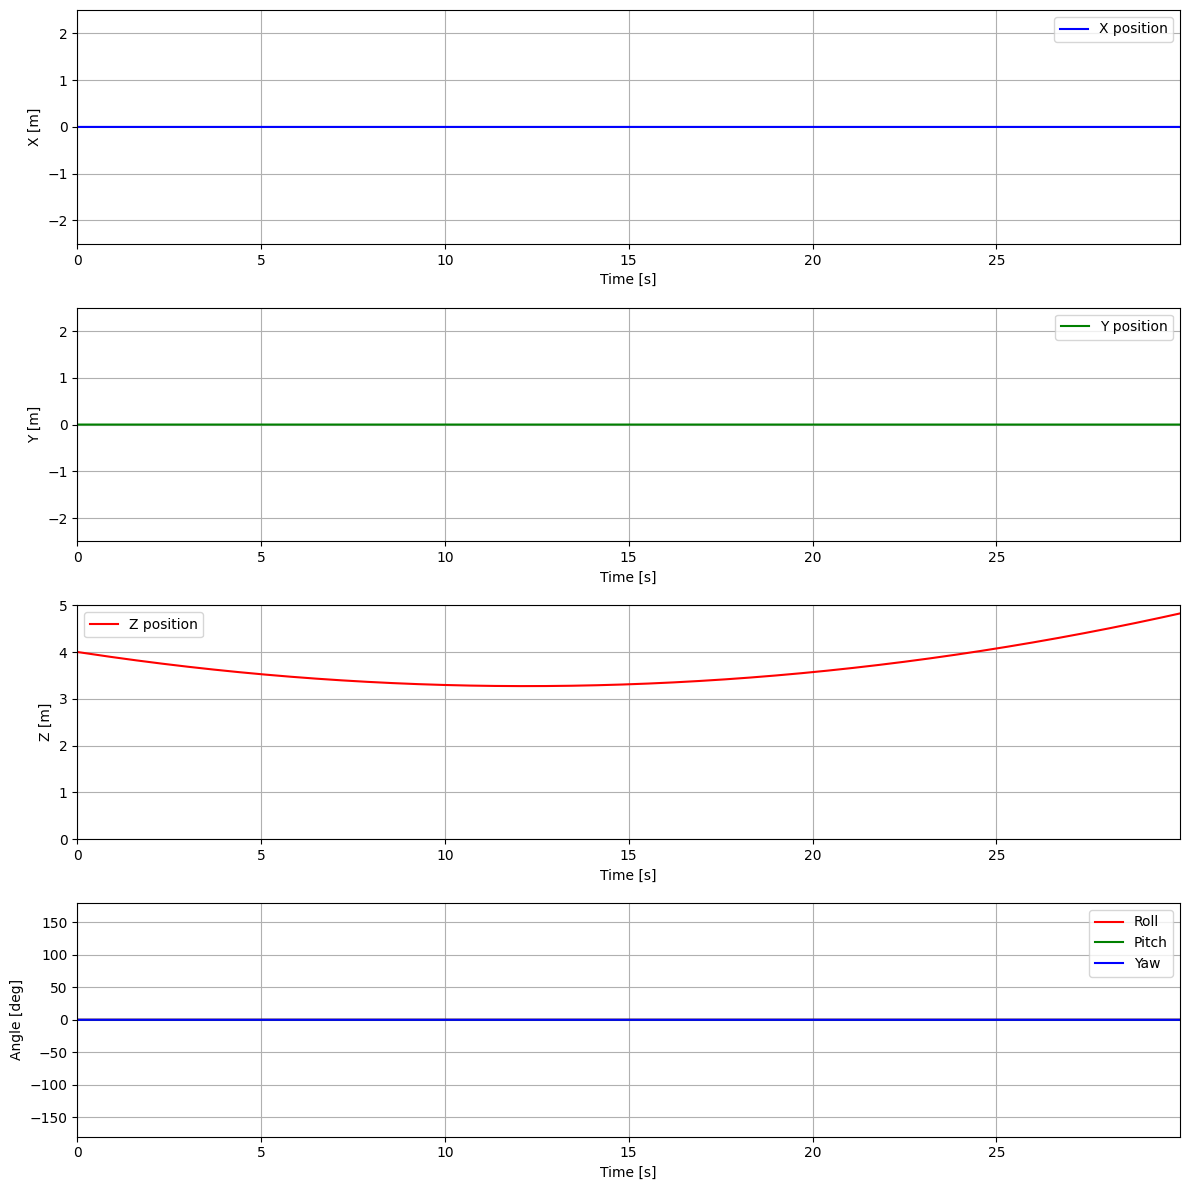


===== Финальное состояние после симуляции =====
Position: [0.         0.         4.82490898]
Angles (deg): Roll=0.0, Pitch=-0.0, Yaw=0.0


In [159]:

steps_forward=2000*3
# Запуск симуляции
pos_log, angles_log, quad = test_forward_motion(steps_forward=steps_forward)

# Создаем фигуру
fig = plt.figure(figsize=(10, 8))

# 3D траектория
ax1 = fig.add_subplot(111, projection='3d')
ax1.plot(pos_log[:, 0], pos_log[:, 1], pos_log[:, 2], 'b-', label='Trajectory')
ax1.scatter(pos_log[0, 0], pos_log[0, 1], pos_log[0, 2], color='g', s=100, label='Start')
ax1.scatter(pos_log[-1, 0], pos_log[-1, 1], pos_log[-1, 2], color='r', s=100, label='End')

# Настройка 3D графика
ax1.set_xlabel('X [m]')
ax1.set_ylabel('Y [m]')
ax1.set_zlabel('Z [m]')
ax1.set_title('Quadrotor Forward Motion')
ax1.legend()

# Установка фиксированного масштаба 5x5x5
ax1.set_xlim([-2.5, 2.5])
ax1.set_ylim([-2.5, 2.5])
ax1.set_zlim([0, 5])

plt.show()

# Вычисляем максимальное время
# Создаем правильный временной массив
time_array = np.arange(len(pos_log)) * (1/200)
max_time = time_array[-1]

# Создаем компоновку графиков: 4 графика в одной колонке
fig2, (ax3, ax4, ax5, ax6) = plt.subplots(4, 1, figsize=(12, 12))

# График X координаты
ax3.plot(time_array, pos_log[:, 0], 'b-', label='X position')
ax3.set_xlabel('Time [s]')
ax3.set_ylabel('X [m]')
ax3.set_ylim([-2.5, 2.5])
ax3.set_xlim([0, max_time])  # Устанавливаем предел по времени
ax3.grid(True)
ax3.legend()

# График Y координаты
ax4.plot(time_array, pos_log[:, 1], 'g-', label='Y position')
ax4.set_xlabel('Time [s]')
ax4.set_ylabel('Y [m]')
ax4.set_ylim([-2.5, 2.5])
ax4.set_xlim([0, max_time])  # Устанавливаем предел по времени
ax4.grid(True)
ax4.legend()

# График Z координаты
ax5.plot(time_array, pos_log[:, 2], 'r-', label='Z position')
ax5.set_xlabel('Time [s]')
ax5.set_ylabel('Z [m]')
ax5.set_ylim([0, 5])
ax5.set_xlim([0, max_time])  # Устанавливаем предел по времени
ax5.grid(True)
ax5.legend()

# График углов
ax6.plot(time_array, np.degrees(angles_log[:, 0]), label='Roll', color='r')
ax6.plot(time_array, np.degrees(angles_log[:, 1]), label='Pitch', color='g')
ax6.plot(time_array, np.degrees(angles_log[:, 2]), label='Yaw', color='b')
ax6.set_xlabel('Time [s]')
ax6.set_ylabel('Angle [deg]')
ax6.set_ylim([-180, 180])
ax6.set_xlim([0, max_time])  # Устанавливаем предел по времени
ax6.grid(True)
ax6.legend()

plt.tight_layout()
plt.show()

# Вывод финального состояния
print("\n===== Финальное состояние после симуляции =====")
print(f"Position: {quad.pos}")
print(f"Angles (deg): Roll={np.degrees(angles_log[-1,0]):.1f}, "
      f"Pitch={np.degrees(angles_log[-1,1]):.1f}, "
      f"Yaw={np.degrees(angles_log[-1,2]):.1f}")



В границах измений величин

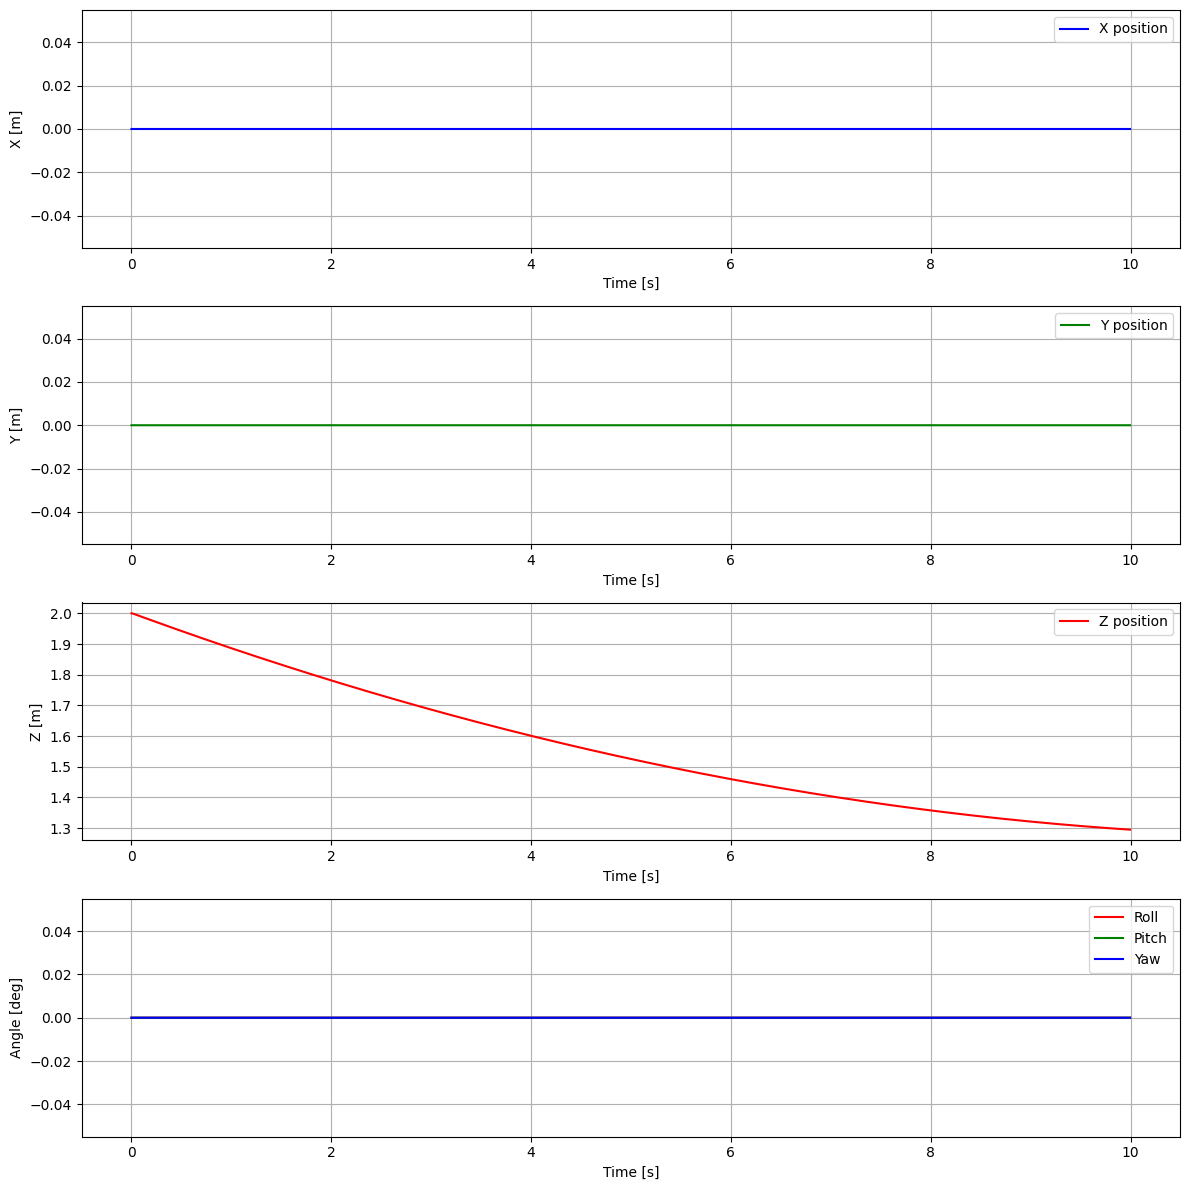

In [157]:
# Создаем компоновку графиков: 4 графика в одной колонке
fig2, (ax3, ax4, ax5, ax6) = plt.subplots(4, 1, figsize=(12, 12))

# График X координаты
ax3.plot(time_array, pos_log[:, 0], 'b-', label='X position')
ax3.set_xlabel('Time [s]')
ax3.set_ylabel('X [m]')
ax3.grid(True)
ax3.legend()

# График Y координаты
ax4.plot(time_array, pos_log[:, 1], 'g-', label='Y position')
ax4.set_xlabel('Time [s]')
ax4.set_ylabel('Y [m]')
ax4.grid(True)
ax4.legend()

# График Z координаты
ax5.plot(time_array, pos_log[:, 2], 'r-', label='Z position')
ax5.set_xlabel('Time [s]')
ax5.set_ylabel('Z [m]')
ax5.grid(True)
ax5.legend()

# График углов
ax6.plot(time_array, np.degrees(angles_log[:, 0]), label='Roll', color='r')
ax6.plot(time_array, np.degrees(angles_log[:, 1]), label='Pitch', color='g')
ax6.plot(time_array, np.degrees(angles_log[:, 2]), label='Yaw', color='b')
ax6.set_xlabel('Time [s]')
ax6.set_ylabel('Angle [deg]')
ax6.grid(True)
ax6.legend()

plt.tight_layout()
plt.show()


### 3D визуализация
